# Phishing URL Detection (Pipeline)

In [11]:
# Importing Basic Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
%matplotlib inline
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [12]:
# Load dataset
df = pd.read_csv('phishing_site_urls.csv')
df.tail()

,URL,Label
549341,23.227.196.215/,bad
549342,apple-checker.org/,bad
549343,apple-iclods.org/,bad
549344,apple-uptoday.org/,bad
549345,apple-search.info,bad


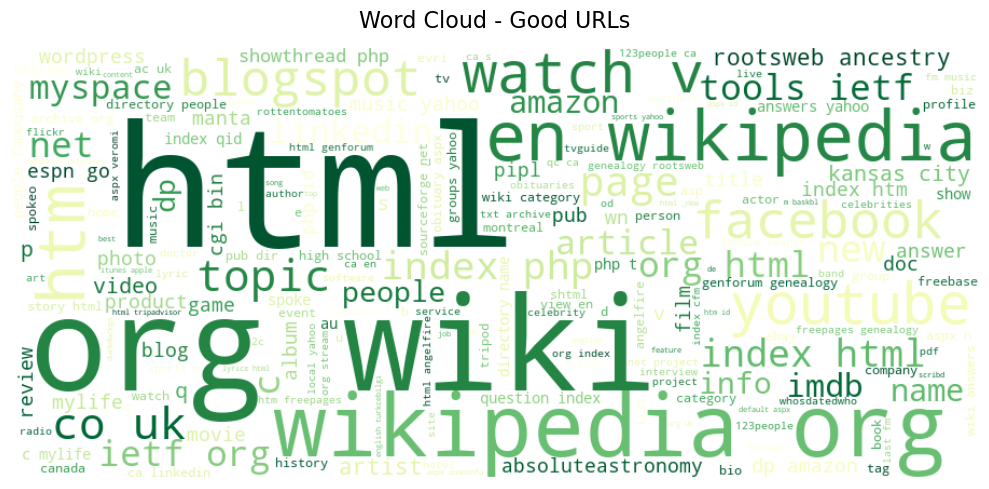

C:\Users\Adesh\AppData\Local\Temp\ipykernel_21312\691833798.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


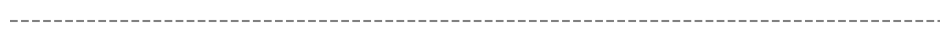

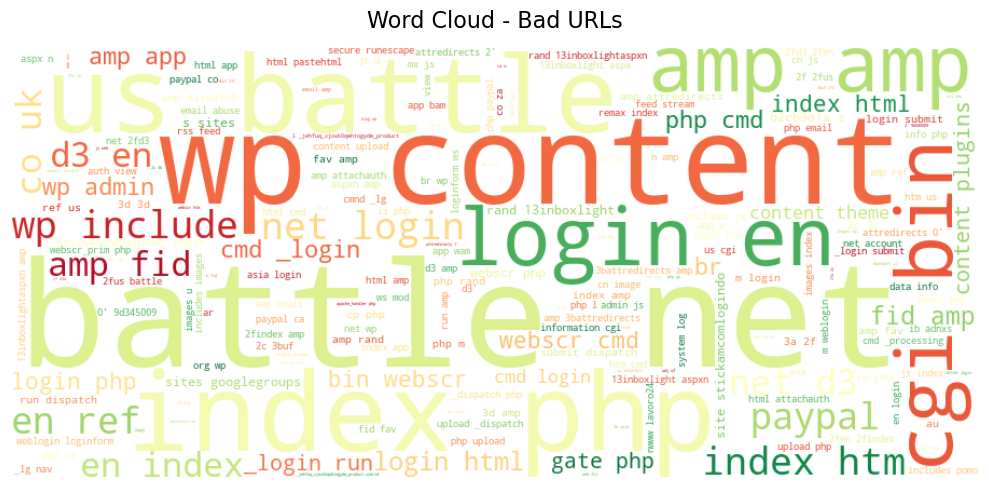

In [15]:
# 1 & 2. Added URL preprocessing & created processed_url column
# Clean URLs before training (remove http, https, www, lowercase)
def clean_url(url):
    url = str(url).lower() # Lowercase
    url = re.sub(r'^https?:\/\/', '', url) # Remove http:// or https://
    url = re.sub(r'^www\.', '', url) # Remove www.
    return url

df['processed_url'] = df['URL'].apply(clean_url)
df[['URL', 'processed_url', 'Label']].head()

# WordCloud for Good URLs
good_urls = df[df['Label'] == 'good']['processed_url']
good_text = ' '.join(good_urls)

wordcloud_good = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='YlGn',
    max_words=200
).generate(good_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_good, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Good URLs', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

# ── Divider line between the two word clouds ──────────────────
fig, ax = plt.subplots(figsize=(12, 0.3))
ax.axhline(y=0.5, color='gray', linewidth=1.5, linestyle='--')
ax.axis('off')
plt.tight_layout()
plt.show()

# WordCloud for Bad URLs
bad_urls = df[df['Label'] == 'bad']['processed_url']
bad_text = ' '.join(bad_urls)

wordcloud_bad = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='RdYlGn',
    max_words=200
).generate(bad_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_bad, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Bad URLs', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

# 6. Fixed train/test pipeline
# Model now trains on cleaned URLs instead of raw text
X = df['processed_url']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (439476,)
Testing set shape: (109870,)


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 3 & 7. Replaced CountVectorizer with TF-IDF and removed .toarray()
# TfidfVectorizer(max_features=5000) for better feature extraction
# Keeping TF-IDF sparse for better performance and memory management
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 4. Removed unnecessary models, kept Logistic Regression only (stable & good for phishing)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_tfidf, y_train)

y_pred = log_model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9344042959861655

Classification Report:
               precision    recall  f1-score   support

         bad       0.94      0.82      0.88     31200
        good       0.93      0.98      0.96     78670

    accuracy                           0.93    109870
   macro avg       0.94      0.90      0.92    109870
weighted avg       0.93      0.93      0.93    109870



In [7]:
# 5. Ensured probability output (supports predict_proba() for Flask confidence score)
sample_urls = [
    'http://www.secure-update-paypal.com/login', 
    'google.com', 
    'https://www.github.com/login'
]

# Test through the entire pipeline (clean -> vectorizer -> predict)
sample_cleaned = [clean_url(url) for url in sample_urls]
sample_tfidf = tfidf.transform(sample_cleaned)

predictions = log_model.predict(sample_tfidf)
probabilities = log_model.predict_proba(sample_tfidf)

for url, pred, prob in zip(sample_urls, predictions, probabilities):
    print(f"URL: {url}")
    print(f"Prediction: {pred}")
    print(f"Probabilities (Classes {log_model.classes_}): {prob}\n")

URL: http://www.secure-update-paypal.com/login
Prediction: bad
Probabilities (Classes ['bad' 'good']): [9.99998926e-01 1.07446273e-06]

URL: google.com
Prediction: good
Probabilities (Classes ['bad' 'good']): [0.41933542 0.58066458]

URL: https://www.github.com/login
Prediction: bad
Probabilities (Classes ['bad' 'good']): [9.99819227e-01 1.80772637e-04]



In [9]:
import pickle

# Save trained model
pickle.dump(log_model, open("url_model.pkl", "wb"))

# Save TF-IDF vectorizer
pickle.dump(tfidf, open("url_tfidf.pkl", "wb"))

print("Model and TF-IDF exported successfully!")

Model and TF-IDF exported successfully!
